In [2]:
import pandas as pd

df = pd.read_csv(
    "Movie_Rating_prediction/IMDb Movies India(sk).csv",
    encoding='latin1'
)

print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi) -2019.0  109 min            Drama   
2                         #Homecoming -2021.0   90 min   Drama, Musical   
3                             #Yaaram -2019.0  110 min  Comedy, Romance   
4                   ...And Once Again -2010.0  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Movie_Rating_prediction/IMDb Movies India(sk).csv", encoding='latin1')

print("=== MOVIE RATING DATA OVERVIEW ===")

# Shape (rows, columns)
print("\nShape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# First 5 rows
print("\nFirst 5 rows:")
print(df.head())

=== MOVIE RATING DATA OVERVIEW ===

Shape: (15509, 10)

Columns:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Data types:
Name            str
Year        float64
Duration        str
Genre           str
Rating      float64
Votes           str
Director        str
Actor 1         str
Actor 2         str
Actor 3         str
dtype: object

Missing values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

First 5 rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi) -2019.0  109 min            Drama   
2                         #Homecoming -2021.0   90 min   Drama, Musical   
3                             #Yaaram -2019.0  110 min  Comedy, Romance   
4               

In [5]:
# 2️⃣ Clean the dataset
# -------------------------------------------------

df_clean = df.copy()   # original data safe rakhne ke liye

# Fix data types - convert numeric columns appropriately
# Year should be numeric (remove negative sign if it's just indicating BCE/CE?)
# Actually looking at the data, some years are negative like -2019, -2021 etc.
# This seems to be a data encoding issue - let's keep as is for now but note it
# Duration has " min" suffix that needs to be removed
# Votes have commas like "1,086" that need to be cleaned
# Rating and others seem okay

# Clean Duration column - remove " min" and convert to numeric
if 'Duration' in df_clean.columns:
    df_clean['Duration'] = df_clean['Duration'].astype(str).str.replace(' min', '', regex=False)
    df_clean['Duration'] = pd.to_numeric(df_clean['Duration'], errors='coerce')

# Clean Votes column - remove commas and convert to numeric
if 'Votes' in df_clean.columns:
    df_clean['Votes'] = df_clean['Votes'].astype(str).str.replace(',', '', regex=False)
    df_clean['Votes'] = pd.to_numeric(df_clean['Votes'], errors='coerce')

# Ensure Year is numeric (it already seems to be, but has negative values)
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')

# Ensure Rating is numeric
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')

# For categorical columns like Genre, Director, Actor fields - keep as object/string
# But we could convert to category if beneficial
cat_cols = ['Name', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# Missing values check
print("\nMissing values BEFORE cleaning:")
print(df_clean.isnull().sum())

# For this dataset, we might want to keep rows with some missing values
# depending on our analysis needs. Let's show what we have.
# But following the mall example pattern, let's drop rows where essential columns are missing
# Essential columns for movie rating prediction: Name, Year, Genre, Rating
essential_cols = ['Name', 'Year', 'Genre', 'Rating']
print(f"\nChecking missing values in essential columns: {essential_cols}")
print(df_clean[essential_cols].isnull().sum())

# Drop rows where essential columns are missing
df_clean = df_clean.dropna(subset=essential_cols)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# 3.5 Final check
print("\n=== CLEANED MOVIE DATA ===")

print("\nShape:", df_clean.shape)

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values AFTER cleaning:")
print(df_clean.isnull().sum())

print("\nFirst 5 rows:")
print(df_clean.head())



Missing values BEFORE cleaning:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7590
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Checking missing values in essential columns: ['Name', 'Year', 'Genre', 'Rating']
Name         0
Year       528
Genre     1877
Rating    7590
dtype: int64

=== CLEANED MOVIE DATA ===

Shape: (7817, 10)

Data types:
Name        category
Year         float64
Duration     float64
Genre       category
Rating       float64
Votes        float64
Director    category
Actor 1     category
Actor 2     category
Actor 3     category
dtype: object

Missing values AFTER cleaning:
Name           0
Year           0
Duration    1997
Genre          0
Rating         0
Votes          0
Director       5
Actor 1      110
Actor 2      176
Actor 3      259
dtype: int64

First 5 rows:
                                 Name    Year  Duration  \
1  #Gadhvi (He thought he was Gandhi) -2019.0     109.0

In [6]:
Save cleaned data
df_clean.to_csv('Movie_rating_prediction_cleaned.csv', index=False)
print("\nCleaned data saved to Movie_rating_prediction_cleaned.csv")

SyntaxError: invalid syntax (197027249.py, line 1)

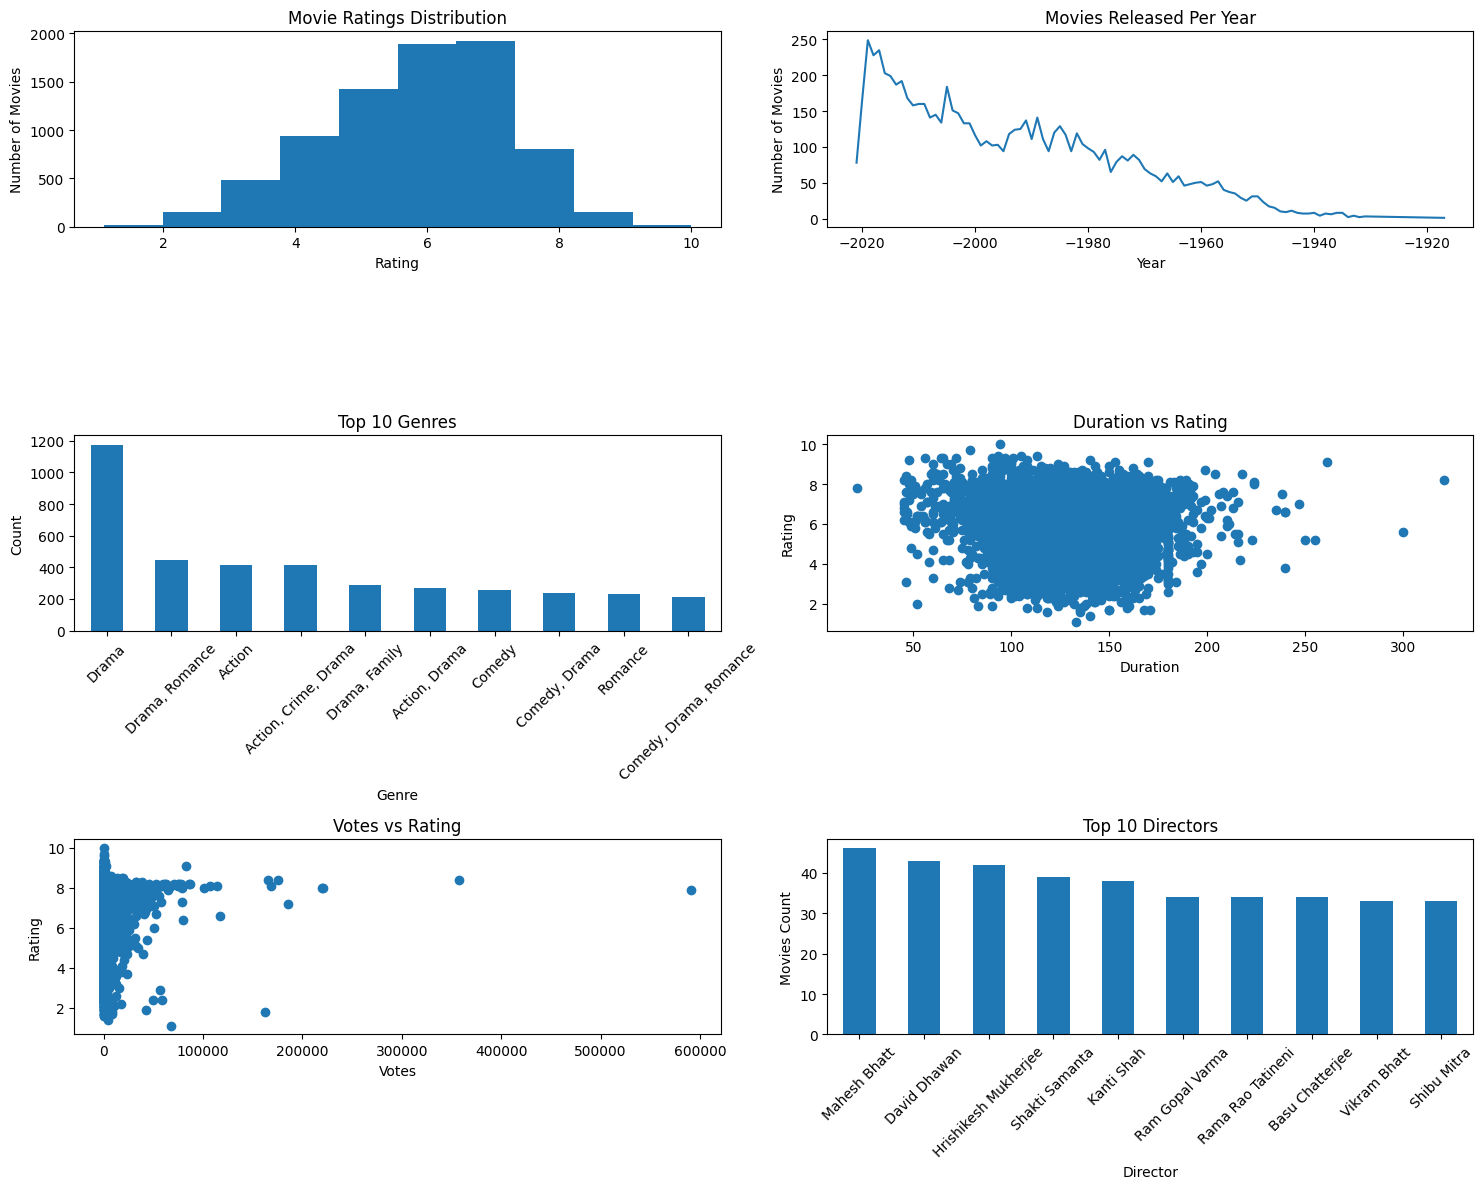

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "Movie_Rating_prediction/Movie_rating_prediction_cleaned.csv",
    encoding='latin1'
)

# Figure Size
plt.figure(figsize=(15, 12))

# 1. Movie Ratings Distribution
plt.subplot(3, 2, 1)

plt.hist(df['Rating'], bins=10)

plt.title("Movie Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")


# 2. Movies Released Per Year
plt.subplot(3, 2, 2)

df['Year'].value_counts().sort_index().plot(kind='line')

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")


# 3. Top 10 Genres
plt.subplot(3, 2, 3)

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)


# 4. Duration vs Rating
plt.subplot(3, 2, 4)

plt.scatter(df['Duration'], df['Rating'])

plt.title("Duration vs Rating")
plt.xlabel("Duration")
plt.ylabel("Rating")


# 5. Votes vs Rating
plt.subplot(3, 2, 5)

plt.scatter(df['Votes'], df['Rating'])

plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")


# 6. Top 10 Directors
plt.subplot(3, 2, 6)

df['Director'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Movies Count")

plt.xticks(rotation=45)


# Adjust Layout
plt.tight_layout()

# Show Graphs
plt.show()